## Data cleaning and EDA 

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
path = r"C:\Users\SVS\Desktop\ML Project\data\ml_ready"
apy = pd.read_csv(path + r"\APY_ML.csv")


In [3]:
apy.shape


(10708, 17)

In [4]:
apy.columns

Index(['id', 'year', 'state_name', 'state_code', 'district_name',
       'district_code', 'crop_name', 'crop_code', 'crop_type', 'season',
       'area', 'area_unit', 'production', 'production_unit', 'yield',
       'yield_unit', 'old_district_name'],
      dtype='object')

In [5]:
apy.head()

,id,year,state_name,state_code,district_name,district_code,crop_name,crop_code,crop_type,season,area,area_unit,production,production_unit,yield,yield_unit,old_district_name
0,385994,2019-2020,Telangana,36,Medak,513,Coriander,509.0,Spices,Rabi,3.0,Hectare,3.0,Tonnes,1.000,Tonnes/Hectare,Medak
1,385995,2019-2020,Telangana,36,Medak,513,Coriander,509.0,Spices,Total,5.0,Hectare,5.0,Tonnes,1.000,Tonnes/Hectare,Medak
2,284901,2014-2015,Telangana,36,Medak,513,Bajra,103.0,Cereals,Rabi,9.0,Hectare,8.0,Tonnes,0.889,Tonnes/Hectare,Medak
3,284691,2014-2015,Telangana,36,Adilabad,501,Arhar/Tur,202.0,Pulses,Kharif,34731.0,Hectare,28618.0,Tonnes,0.824,Tonnes/Hectare,Adilabad
4,284692,2014-2015,Telangana,36,Adilabad,501,Arhar/Tur,202.0,Pulses,Rabi,543.0,Hectare,447.0,Tonnes,0.823,Tonnes/Hectare,Adilabad


In [6]:
apy.dtypes

id                     int64
year                  object
state_name            object
state_code             int64
district_name         object
district_code          int64
crop_name             object
crop_code            float64
crop_type             object
season                object
area                 float64
area_unit             object
production           float64
production_unit       object
yield                float64
yield_unit            object
old_district_name     object
dtype: object

In [7]:
apy.isnull().sum()

id                    0
year                  0
state_name            0
state_code            0
district_name         0
district_code         0
crop_name             0
crop_code             0
crop_type             0
season                0
area                  0
area_unit             0
production           44
production_unit       0
yield                 0
yield_unit            0
old_district_name     0
dtype: int64

In [8]:
## filling productiong using  formulae area* yield
Production = (
    apy["production"].isnull()
    & apy["area"].notnull()
    & apy["yield"].notnull()
)

apy.loc[Production, "production"] = (
    apy.loc[Production, "area"] *
    apy.loc[Production, "yield"]
)


# Check remaining production nulls
print(
    "\nRemaining production nulls:",
    apy["production"].isnull().sum()
)



Remaining production nulls: 0


In [9]:
apy.isnull().sum()

id                   0
year                 0
state_name           0
state_code           0
district_name        0
district_code        0
crop_name            0
crop_code            0
crop_type            0
season               0
area                 0
area_unit            0
production           0
production_unit      0
yield                0
yield_unit           0
old_district_name    0
dtype: int64

In [10]:
apy['season'].unique()

array(['Rabi', 'Total', 'Kharif', 'Whole Year'], dtype=object)

In [11]:
## replacing total with All seasons 
apy["season"] = apy["season"].replace( "Total", "All Seasons")

In [12]:
apy['season'].unique()

array(['Rabi', 'All Seasons', 'Kharif', 'Whole Year'], dtype=object)

In [13]:
apy[["area", "production", "yield"]].describe()

,area,production,yield
count,10708.000000,1.070800e+04,10708.000000
mean,9064.124767,3.096766e+04,9.600298
std,28919.326297,1.347578e+05,288.654434
min,1.000000,0.000000e+00,0.000000
25%,19.000000,2.900000e+01,0.842000
50%,164.000000,3.240000e+02,1.627500
75%,2393.250000,5.778000e+03,3.747000
max,429354.000000,9.222885e+06,21105.000000


In [14]:
print("\nNumber of crops:", apy["crop_name"].nunique())
print("\nCrop names:")
print(sorted(apy["crop_name"].dropna().unique()))


Number of crops: 40

Crop names:
['Arhar/Tur', 'Bajra', 'Banana', 'Cashewnut', 'Castor Seed', 'Coconut', 'Coriander', 'Cotton(Lint)', 'Cowpea(Lobia)', 'Dry Chillies', 'Garlic', 'Ginger', 'Gram', 'Groundnut', 'Horse-Gram', 'Jowar', 'Linseed', 'Maize', 'Masoor', 'Mesta', 'Moong(Green Gram)', 'Onion', 'Other Kharif Pulses', 'Other Oilseeds', 'Other Rabi Pulses', 'Potato', 'Ragi', 'Rapeseed &Mustard', 'Rice', 'Safflower', 'Sesamum', 'Small Millets', 'Soyabean', 'Sugarcane', 'Sunflower', 'Sweet Potato', 'Tobacco', 'Turmeric', 'Urad', 'Wheat']


## EDA 

In [54]:
## crop distribution 
print("Number of crops:", apy["crop_name"].nunique())
print(apy["crop_name"] .value_counts().head(20))

Number of crops: 40
crop_name
Rice                 714
Maize                712
Moong(Green Gram)    662
Groundnut            613
Urad                 612
Dry Chillies         603
Jowar                594
Cowpea(Lobia)        540
Arhar/Tur            530
Onion                513
Sesamum              498
Castor Seed          349
Horse-Gram           340
Cotton(Lint)         302
Sunflower            278
Gram                 270
Soyabean             257
Bajra                247
Turmeric             244
Banana               200
Name: count, dtype: int64


In [15]:
## crop type distribution 
print(apy["crop_type"].value_counts())

crop_type
Pulses                 2967
Cereals                2739
Oilseeds               2160
Spices                 1194
Vegetable               714
Fiber Crops             305
Fruits                  257
Drugs And Narcotics     199
Sugar                   173
Name: count, dtype: int64


In [16]:
## season distribution 
print(apy["season"].value_counts())

season
Kharif         4115
Rabi           3929
All Seasons    2655
Whole Year        9
Name: count, dtype: int64


In [17]:
## year distribution 
print(apy["year"].value_counts().sort_index())

year
2014-2015     455
2015-2016     460
2016-2017    1163
2017-2018    1081
2018-2019    1116
2019-2020    1352
2020-2021    1585
2021-2022    1843
2022-2023    1653
Name: count, dtype: int64


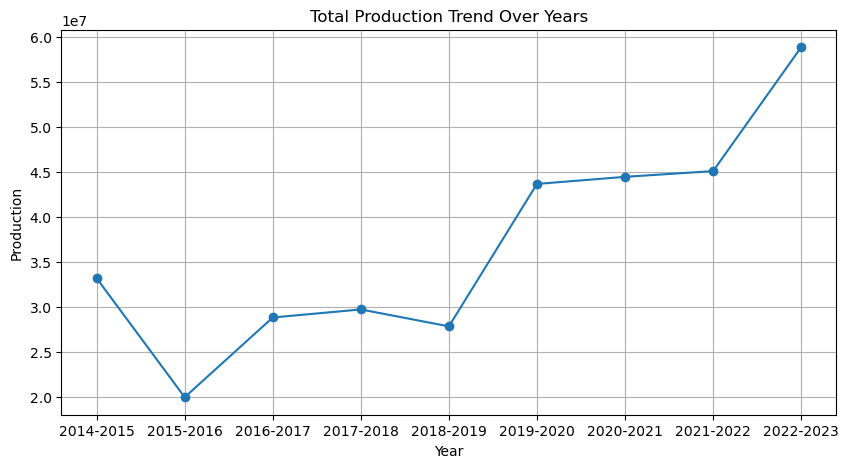

In [18]:
## year production 
year_production = ( apy.groupby("year")["production"] .sum().sort_index())

year_production.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Total Production Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid()
plt.show()

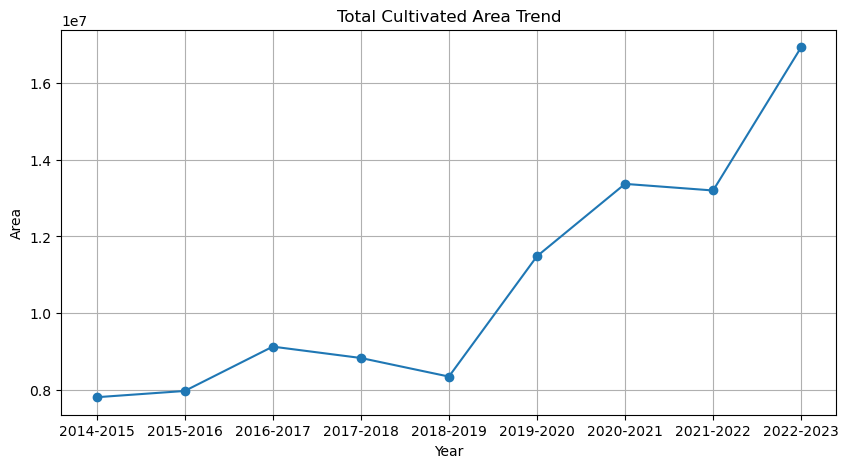

In [19]:
## year area 
year_area = ( apy.groupby("year")["area"] .sum() .sort_index())

year_area.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Total Cultivated Area Trend")
plt.xlabel("Year")
plt.ylabel("Area")
plt.grid()
plt.show()

In [20]:
## correlation
print( apy[  ["area", "production", "yield"]  ].corr())


                area  production     yield
area        1.000000    0.660204 -0.006715
production  0.660204    1.000000  0.469538
yield      -0.006715    0.469538  1.000000


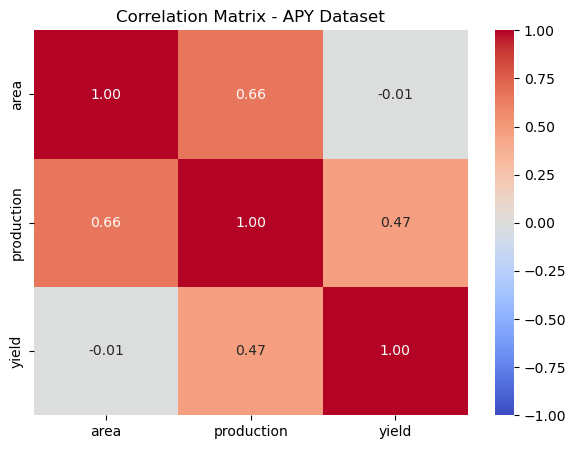

In [21]:
corr = apy[["area", "production", "yield"]].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix - APY Dataset")
plt.show()

In [22]:
## crop perecntage 
crop_percentage = (
    apy["crop_name"]
    .value_counts(normalize=True)
    .head(15) * 100
)

print(crop_percentage)

crop_name
Rice                 6.667912
Maize                6.649234
Moong(Green Gram)    6.182294
Groundnut            5.724692
Urad                 5.715353
Dry Chillies         5.631304
Jowar                5.547254
Cowpea(Lobia)        5.042959
Arhar/Tur            4.949570
Onion                4.790811
Sesamum              4.650728
Castor Seed          3.259245
Horse-Gram           3.175196
Cotton(Lint)         2.820321
Sunflower            2.596190
Name: proportion, dtype: float64


## Feature Enginerring 

In [23]:
## year start 
apy["year_start"] = (apy["year"].astype(str).str[:4].astype(int))

In [24]:
## Previous year yield
apy = apy.sort_values(
    ["old_district_name", "crop_name", "season", "year_start"]
)

In [25]:
apy["previous_year_yield"] = (apy.groupby( ["old_district_name", "crop_name", "season"])["yield"].shift(1))

In [26]:
print(
    apy[
        [
            "old_district_name",
            "crop_name",
            "season",
            "year",
            "yield",
            "previous_year_yield"
        ]
    ].head(20)
)

     old_district_name  crop_name       season       year  yield  \
5             Adilabad  Arhar/Tur  All Seasons  2014-2015  0.824   
460           Adilabad  Arhar/Tur  All Seasons  2015-2016  1.008   
919           Adilabad  Arhar/Tur  All Seasons  2016-2017  1.104   
1303          Adilabad  Arhar/Tur  All Seasons  2016-2017  1.104   
1421          Adilabad  Arhar/Tur  All Seasons  2016-2017  1.104   
1607          Adilabad  Arhar/Tur  All Seasons  2016-2017  1.104   
2442          Adilabad  Arhar/Tur  All Seasons  2017-2018  0.717   
2563          Adilabad  Arhar/Tur  All Seasons  2017-2018  0.573   
3500          Adilabad  Arhar/Tur  All Seasons  2018-2019  1.041   
3609          Adilabad  Arhar/Tur  All Seasons  2018-2019  0.792   
4814          Adilabad  Arhar/Tur  All Seasons  2019-2020  0.687   
5629          Adilabad  Arhar/Tur  All Seasons  2020-2021  0.907   
6114          Adilabad  Arhar/Tur  All Seasons  2020-2021  1.129   
6257          Adilabad  Arhar/Tur  All Seasons  

In [27]:
## Historical average yield
apy = apy.sort_values(
    ["old_district_name", "crop_name", "season", "year_start"]
)

In [28]:
apy["historical_avg_yield"] = (
    apy.groupby(
        ["old_district_name", "crop_name", "season"]
    )["yield"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

In [29]:
print(
    apy[
        [
            "old_district_name",
            "crop_name",
            "season",
            "year",
            "yield",
            "historical_avg_yield"
        ]
    ].head(20)
)

     old_district_name  crop_name       season       year  yield  \
5             Adilabad  Arhar/Tur  All Seasons  2014-2015  0.824   
460           Adilabad  Arhar/Tur  All Seasons  2015-2016  1.008   
919           Adilabad  Arhar/Tur  All Seasons  2016-2017  1.104   
1303          Adilabad  Arhar/Tur  All Seasons  2016-2017  1.104   
1421          Adilabad  Arhar/Tur  All Seasons  2016-2017  1.104   
1607          Adilabad  Arhar/Tur  All Seasons  2016-2017  1.104   
2442          Adilabad  Arhar/Tur  All Seasons  2017-2018  0.717   
2563          Adilabad  Arhar/Tur  All Seasons  2017-2018  0.573   
3500          Adilabad  Arhar/Tur  All Seasons  2018-2019  1.041   
3609          Adilabad  Arhar/Tur  All Seasons  2018-2019  0.792   
4814          Adilabad  Arhar/Tur  All Seasons  2019-2020  0.687   
5629          Adilabad  Arhar/Tur  All Seasons  2020-2021  0.907   
6114          Adilabad  Arhar/Tur  All Seasons  2020-2021  1.129   
6257          Adilabad  Arhar/Tur  All Seasons  

In [30]:
## Previous Year Production
apy = apy.sort_values(
    ["old_district_name", "crop_name", "season", "year_start"]
)

In [31]:
apy["previous_year_production"] = (
    apy.groupby(
        ["old_district_name", "crop_name", "season"]
    )["production"]
    .shift(1)
)

In [32]:
print(
    apy[
        [
            "old_district_name",
            "crop_name",
            "season",
            "year",
            "production",
            "previous_year_production"
        ]
    ].head(20)
)

     old_district_name  crop_name       season       year  production  \
5             Adilabad  Arhar/Tur  All Seasons  2014-2015     29065.0   
460           Adilabad  Arhar/Tur  All Seasons  2015-2016     38229.0   
919           Adilabad  Arhar/Tur  All Seasons  2016-2017     22165.0   
1303          Adilabad  Arhar/Tur  All Seasons  2016-2017     20243.0   
1421          Adilabad  Arhar/Tur  All Seasons  2016-2017      5934.0   
1607          Adilabad  Arhar/Tur  All Seasons  2016-2017      7603.0   
2442          Adilabad  Arhar/Tur  All Seasons  2017-2018     10035.0   
2563          Adilabad  Arhar/Tur  All Seasons  2017-2018      1404.0   
3500          Adilabad  Arhar/Tur  All Seasons  2018-2019     12251.0   
3609          Adilabad  Arhar/Tur  All Seasons  2018-2019      1544.0   
4814          Adilabad  Arhar/Tur  All Seasons  2019-2020      1041.0   
5629          Adilabad  Arhar/Tur  All Seasons  2020-2021     22707.0   
6114          Adilabad  Arhar/Tur  All Seasons  202

In [33]:
## Previous year area
apy["previous_year_area"] = (
    apy.groupby(["old_district_name", "crop_name", "season"])["area"].shift(1)
)

In [34]:
print(
    apy[
        [
            "old_district_name",
            "crop_name",
            "season",
            "year",
            "area",
            "previous_year_area"
        ]
    ].head(20)
)

     old_district_name  crop_name       season       year     area  \
5             Adilabad  Arhar/Tur  All Seasons  2014-2015  35274.0   
460           Adilabad  Arhar/Tur  All Seasons  2015-2016  37926.0   
919           Adilabad  Arhar/Tur  All Seasons  2016-2017  20077.0   
1303          Adilabad  Arhar/Tur  All Seasons  2016-2017  18336.0   
1421          Adilabad  Arhar/Tur  All Seasons  2016-2017   5375.0   
1607          Adilabad  Arhar/Tur  All Seasons  2016-2017   6887.0   
2442          Adilabad  Arhar/Tur  All Seasons  2017-2018  13996.0   
2563          Adilabad  Arhar/Tur  All Seasons  2017-2018   2451.0   
3500          Adilabad  Arhar/Tur  All Seasons  2018-2019  11769.0   
3609          Adilabad  Arhar/Tur  All Seasons  2018-2019   1949.0   
4814          Adilabad  Arhar/Tur  All Seasons  2019-2020   1515.0   
5629          Adilabad  Arhar/Tur  All Seasons  2020-2021  25042.0   
6114          Adilabad  Arhar/Tur  All Seasons  2020-2021  15812.0   
6257          Adilab

In [35]:
apy.isnull().sum()

id                            0
year                          0
state_name                    0
state_code                    0
district_name                 0
district_code                 0
crop_name                     0
crop_code                     0
crop_type                     0
season                        0
area                          0
area_unit                     0
production                    0
production_unit               0
yield                         0
yield_unit                    0
old_district_name             0
year_start                    0
previous_year_yield         759
historical_avg_yield        759
previous_year_production    759
previous_year_area          759
dtype: int64

## Univariate Analysis 

In [77]:
## Crop Distribution
print(apy["crop_name"].value_counts())

crop_name
Rice                   714
Maize                  712
Moong(Green Gram)      662
Groundnut              613
Urad                   612
Dry Chillies           603
Jowar                  594
Cowpea(Lobia)          540
Arhar/Tur              530
Onion                  513
Sesamum                498
Castor Seed            349
Horse-Gram             340
Cotton(Lint)           302
Sunflower              278
Gram                   270
Soyabean               257
Bajra                  247
Turmeric               244
Banana                 200
Tobacco                199
Ragi                   194
Sugarcane              173
Coriander              172
Wheat                  150
Safflower              149
Small Millets          128
Ginger                 116
Sweet Potato           114
Potato                  87
Garlic                  59
Cashewnut               57
Rapeseed &Mustard        6
Other Kharif Pulses      6
Other Oilseeds           6
Other Rabi Pulses        5
Mesta             

In [36]:
print(apy["season"].value_counts())

season
Kharif         4115
Rabi           3929
All Seasons    2655
Whole Year        9
Name: count, dtype: int64


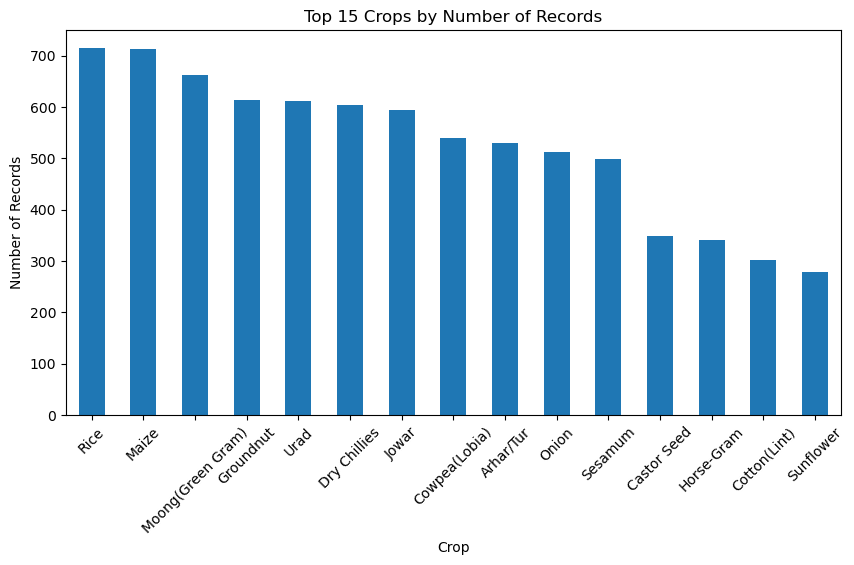

In [78]:
apy["crop_name"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 15 Crops by Number of Records")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [79]:
print(apy["season"].value_counts())

season
Kharif         4115
Rabi           3929
All Seasons    2655
Whole Year        9
Name: count, dtype: int64


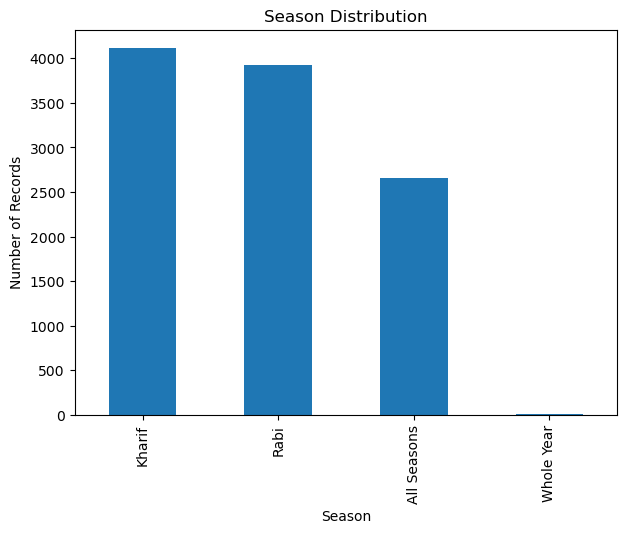

In [80]:
apy["season"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Season Distribution")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()

## Bivariate Analysis 

In [38]:
## District vs Yield
district_yield = (
    apy.groupby("old_district_name")["yield"]
    .mean()
    .sort_values(ascending=False)
)

print(district_yield)

old_district_name
Khammam         36.958374
Ranga Reddy     25.162198
Nizamabad        6.431870
Karimnagar       5.956954
Medak            5.814652
Nalgonda         5.704241
Adilabad         5.407357
Warangal         5.226275
Mahabubnagar     5.217410
Name: yield, dtype: float64


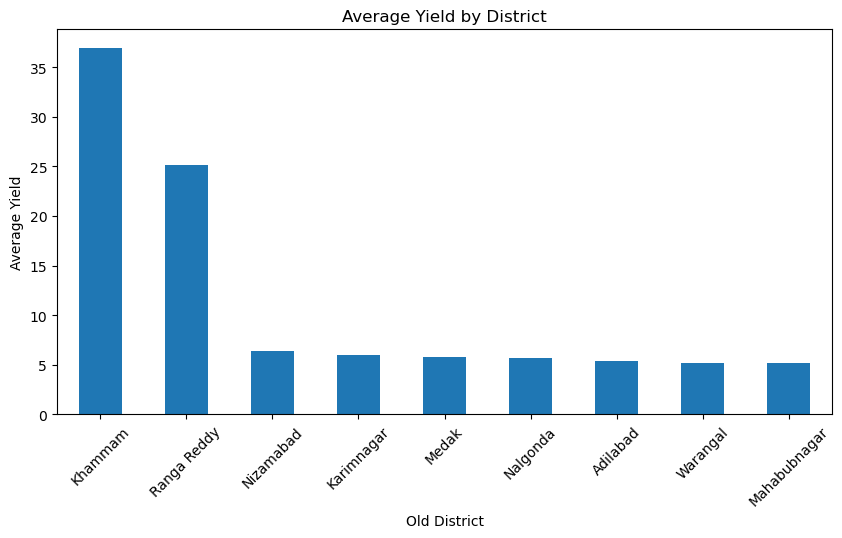

In [39]:
district_yield.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Yield by District")
plt.xlabel("Old District")
plt.ylabel("Average Yield")
plt.xticks(rotation=45)
plt.show()

In [40]:
## Season vs Yield
print(
    apy.groupby("season")["yield"]
    .mean()
    .sort_values(ascending=False)
)

season
Whole Year     4690.186778
Kharif            8.550254
Rabi              4.008936
All Seasons       3.635744
Name: yield, dtype: float64


In [42]:
## Crop vs Yield
apy.groupby("crop_name")["yield"].mean().sort_values(ascending=False)

crop_name
Coconut                21105.000000
Sugarcane                 84.478341
Banana                    49.998625
Onion                     24.639107
Other Oilseeds            16.354167
Potato                    16.176874
Sweet Potato              10.047009
Ginger                     8.184828
Mesta                      7.107000
Turmeric                   6.797369
Maize                      5.252743
Dry Chillies               4.565806
Rice                       3.320127
Tobacco                    3.166844
Cotton(Lint)               2.734305
Garlic                     2.438915
Groundnut                  2.167091
Wheat                      1.903173
Sunflower                  1.889011
Soyabean                   1.511677
Gram                       1.413481
Ragi                       1.401464
Jowar                      1.340899
Rapeseed &Mustard          1.320000
Bajra                      1.146093
Small Millets              1.059586
Urad                       1.051217
Cowpea(Lobia)     

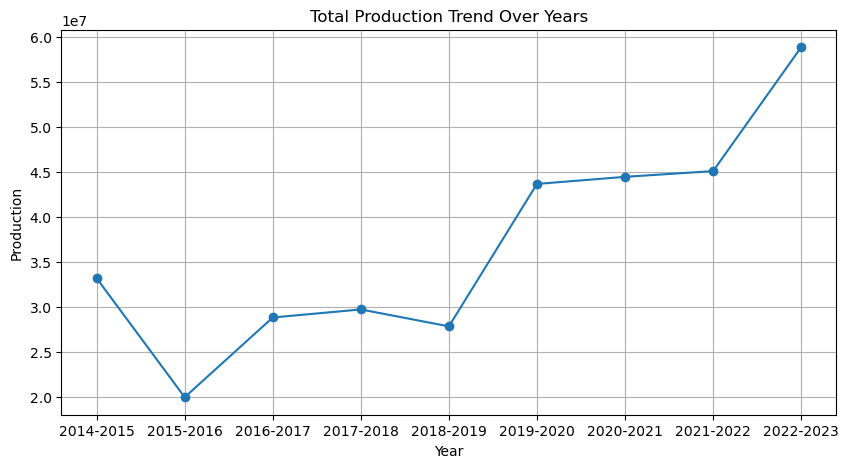

In [43]:
## Total Production Trend Over Years
year_production = (
    apy.groupby("year")["production"]
    .sum()
    .sort_index()
)

year_production.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Total Production Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid()
plt.show()

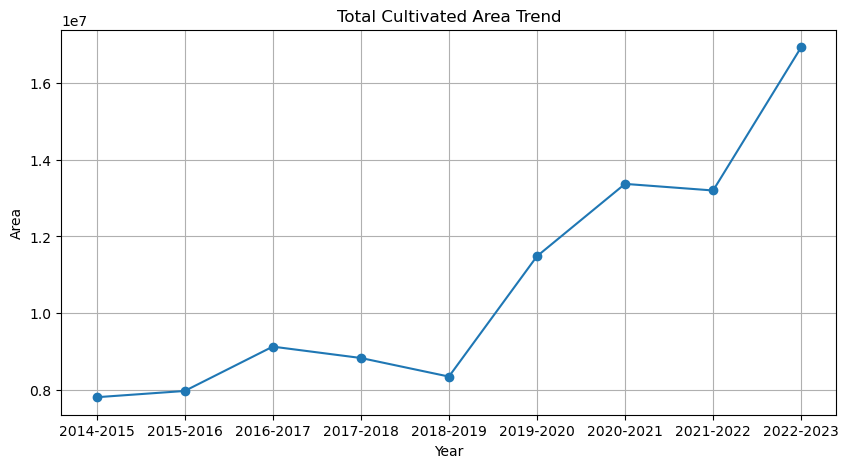

In [44]:
## Total Cultivated Area Trend
year_area = (
    apy.groupby("year")["area"]
    .sum()
    .sort_index()
)

year_area.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Total Cultivated Area Trend")
plt.xlabel("Year")
plt.ylabel("Area")
plt.grid()
plt.show()

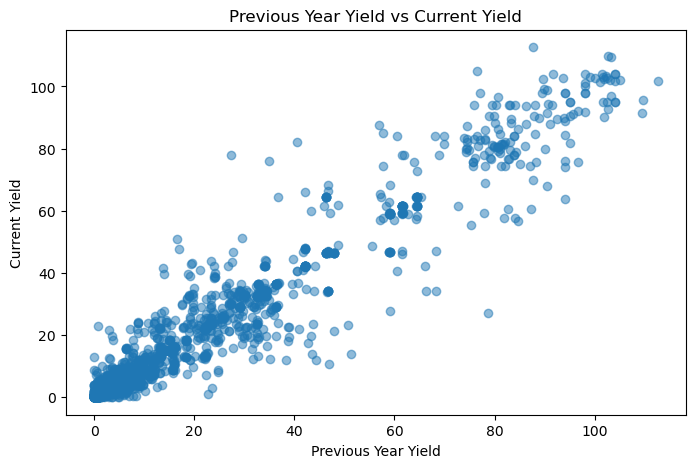

In [45]:
## Previous-year Yield vs Current Yield
plt.figure(figsize=(8,5))

plt.scatter(
    apy["previous_year_yield"],
    apy["yield"],
    alpha=0.5
)

plt.title("Previous Year Yield vs Current Yield")
plt.xlabel("Previous Year Yield")
plt.ylabel("Current Yield")
plt.show()

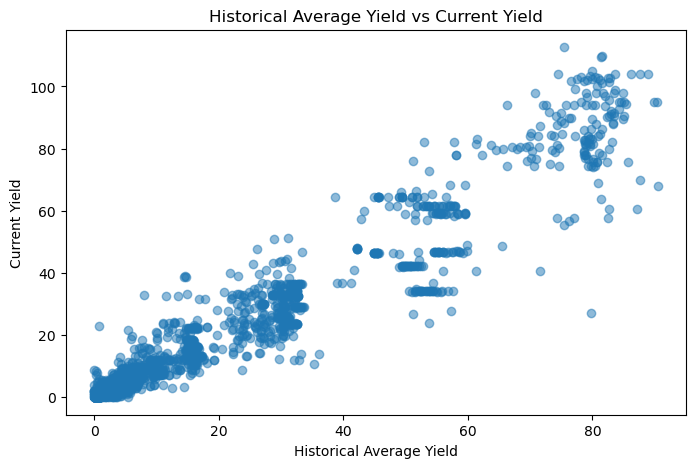

In [46]:
## Historical Average Yield vs Current Yield
plt.figure(figsize=(8,5))

plt.scatter(
    apy["historical_avg_yield"],
    apy["yield"],
    alpha=0.5
)

plt.title("Historical Average Yield vs Current Yield")
plt.xlabel("Historical Average Yield")
plt.ylabel("Current Yield")
plt.show()

## Multivariate Analysis 

In [47]:
## Correlation Matrix
numeric_cols = [
    "area",
    "production",
    "yield",
    "previous_year_production",
    "previous_year_area"
]

corr = apy[numeric_cols].corr()

print(corr)

                              area  production     yield  \
area                      1.000000    0.660204 -0.006715   
production                0.660204    1.000000  0.469538   
yield                    -0.006715    0.469538  1.000000   
previous_year_production  0.698778    0.714342  0.092502   
previous_year_area        0.764319    0.691797 -0.056159   

                          previous_year_production  previous_year_area  
area                                      0.698778            0.764319  
production                                0.714342            0.691797  
yield                                     0.092502           -0.056159  
previous_year_production                  1.000000            0.874399  
previous_year_area                        0.874399            1.000000  


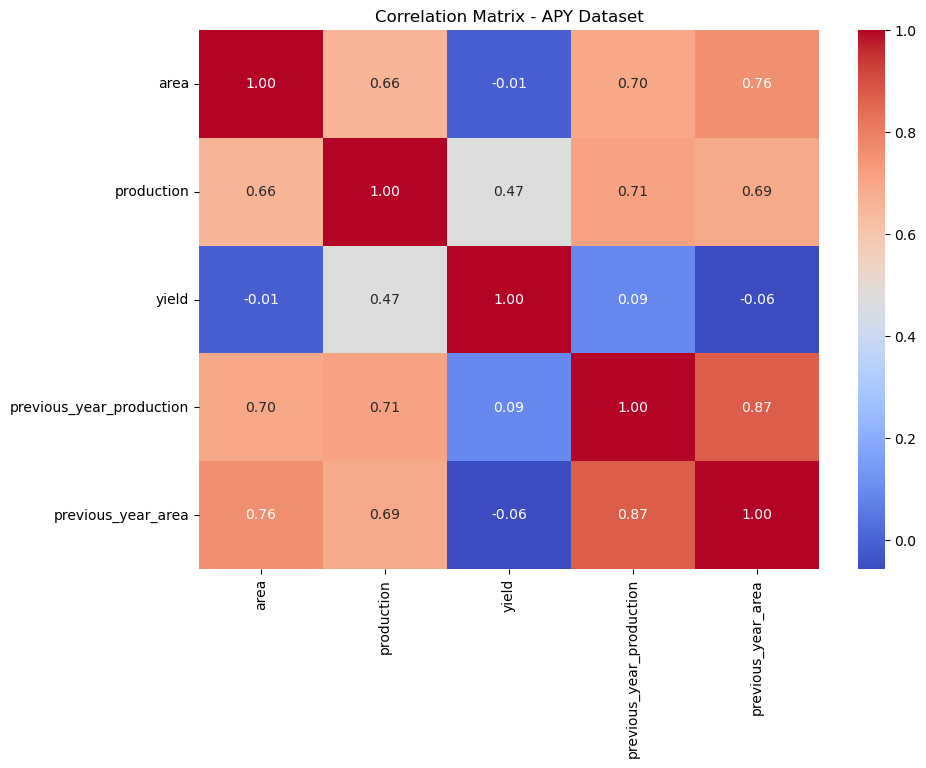

In [48]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - APY Dataset")
plt.show()

In [49]:
## Crop + Season + Yield
crop_season_yield = (
    apy.groupby(
        ["crop_name", "season"]
    )["yield"]
    .mean()
    .reset_index()
    .sort_values("yield", ascending=False)
)

print(crop_season_yield)

    crop_name       season         yield
11    Coconut   Whole Year  21105.000000
82  Sugarcane       Kharif     84.478341
6      Banana       Kharif     49.998625
56      Onion         Rabi     29.496381
54      Onion  All Seasons     26.591869
..        ...          ...           ...
43    Linseed         Rabi      0.414500
7   Cashewnut       Kharif      0.412000
47     Masoor         Rabi      0.368500
15  Coriander   Whole Year      0.240143
74    Sesamum       Kharif      0.161684

[101 rows x 3 columns]


In [50]:
## District + Crop + Yield
district_crop_yield = (
    apy.groupby(
        ["district_name", "crop_name"]
    )["yield"]
    .mean()
    .reset_index()
    .sort_values("yield", ascending=False)
)

print(district_crop_yield.head(20))

                district_name  crop_name         yield
273                   Khammam    Coconut  21105.000000
713               Ranga Reddy    Coconut  21105.000000
408                Mancherial  Sugarcane    104.000000
323    Kumuram Bheem Asifabad  Sugarcane     94.625000
473        Medchal Malkajgiri  Sugarcane     94.000000
526              Nagarkurnool  Sugarcane     90.049333
144                   Jangoan  Sugarcane     89.800000
613                    Nirmal  Sugarcane     89.666500
586                Narayanpet  Sugarcane     89.643000
702          Rajanna Sircilla  Sugarcane     88.888167
798                  Siddipet  Sugarcane     88.021833
28                   Adilabad  Sugarcane     87.504667
825                  Suryapet  Sugarcane     87.477143
350               Mahabubabad  Sugarcane     86.960714
229                 Kamareddy  Sugarcane     86.477857
941       Yadadri Bhuvanagiri  Sugarcane     85.365143
556                  Nalgonda  Sugarcane     84.755889
57       B

In [54]:
ml_path = r"C:\Users\SVS\Desktop\ML Project\data\ml_ready"
apy.to_csv(
    ml_path + r"\APY_Clean.csv",
    index=False
)

print("APY_Clean.csv saved successfully.")

APY_Clean.csv saved successfully.


## Insights 
- Area and Production have a positive relationship
  The  production generally increases as cultivated area increases. However, a larger cultivated area does not automatically mean higher yield.
- Area has very little direct relationship with Yield
  The cultivated area is related to total production but has almost no direct relationship with yield. This shows that production and productivity should be considered separately.means  larger land area does not necessarily result in higher productivity.

- Khammam had an average yield of approximately 36.96, while Ranga Reddy had approximately 25.16, whereas several other districts were around 5–6. This shows a large variation in crop productivity between districts, indicating that location is an important factor in agricultural performance.
- Year Production and Previous-Year Area have a strong correlation of 0.8744.
 Larger cultivated areas in the previous year are strongly associated with higher previous production. These historical features contain useful information but may also have overlapping information for ML models.